# Candidate Selector

csv file structure:
```
entity_label,start_position,end_position,correct_prediction,candidates,matching_candidate_index
Bandar Seri Begawan,0,19,True,"[[""Bandar Seri Begawan"", 0.942, 1.0, 0.839, 0.354], [""Pusat Bandar, Brunei"", 0.937, 0.46, 0.289, 0.348], [""1999 Southeast Asian Games"", 0.943, 0.27, 0.349, 0.189], [""List of diplomatic missions of Russia"", 0, 0.21, 1.0, 0.087], [""List of diplomatic missions of India"", 0, 0.22, 0.889, 0.161], [""Embassy of the Philippines, Bandar Seri Begawan"", 0, 0.58, 0.124, 0.45], [""Bandar Seri Begawan"", 0, 1.0, 0.0, 0.147], [""Bandar Seri Begawan"", 0, 1.0, 0.0, 0.147], [""Flughafen Bandar Seri Begawan"", 0, 0.79, 0.0, 0.147], [""Deutsche Botschaft Bandar Seri Begawan"", 0, 0.67, 0.0, 0.147]]",0
AFP,26,29,False,"[[""AFC Ajax"", 0.694, 0.36, 0.937, -0.12], [""AFC Wimbledon"", 0.694, 0.25, 0.806, 0.007], [""Sunderland A.F.C."", 0.694, 0.2, 1.0, -0.148], [""Armed Forces of the Philippines"", 0.692, 0.18, 0.463, 0.302], [""Agence France-Presse"", 0.652, 0.26, 0.356, 0.226], [""Alpha-fetoprotein"", 0.887, 0.1, 0.345, 0.057], [""AFP"", 0, 1.0, 0.056, 0.147], [""AFP-L3"", 0, 0.67, 0.0, 0.147], [""Armed Forces of the Philippines Medal of Valor"", 0, 0.12, 0.423, 0.126], [""AFP Visayas Command"", 0, 0.27, 0.0, 0.147]]",4
White House,343,354,False,"[[""White"", 0.874, 0.62, 1.0, -0.015], [""White House"", 0.76, 1.0, 0.295, 0.072], [""Chicago White Sox"", 0.686, 0.5, 0.888, -0.056], [""Vale of White Horse"", 0.813, 0.67, 0.471, -0.09], [""White House Office"", 0.707, 0.76, 0.0, 0.133], [""White-shouldered house moth"", 0.844, 0.53, 0.096, 0.085], [""White House Correspondents' Association"", 0.691, 0.44, 0.115, 0.223], [""White House, Tennessee"", 0.809, 0.67, 0.041, -0.061], [""White House Press Secretary"", 0, 0.58, 0.028, 0.216], [""White House COVID-19 outbreak"", 0, 0.55, 0.123, 0.144]]",1

```

In [1]:
import pandas as pd
import ast
import os
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import euclidean
import joblib
from tqdm import tqdm  
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report

2025-04-09 17:14:42.143390: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-09 17:14:42.150413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-09 17:14:42.158640: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-09 17:14:42.161092: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-09 17:14:42.167421: I tensorflow/core/platform/cpu_feature_guar

In [25]:
directory_path = "./logs"  # Change this to your directory path

# List all CSV files in the directory
csv_files = [f for f in os.listdir(directory_path) if f.endswith(".csv")]

# Read and concatenate all CSV files
dataframes = []
for file in csv_files:
    file_path = os.path.join(directory_path, file)
    df = pd.read_csv(file_path, encoding="utf-16")
    df["candidates"] = df["candidates"].apply(ast.literal_eval)
    dataframes.append(df)

# Combine all dataframes into one
final_df = pd.concat(dataframes, ignore_index=True)

# Display first few rows
print(final_df.head())
print(final_df.info())

  entity_label  start_position  end_position  correct_prediction  \
0     BRUSSELS              65            73                True   
1       German             144           150                True   
2      British             179           186                True   
3      Germany             273           280                True   
4      Britain             437           444                True   

                                          candidates  matching_candidate_index  
0  [[Brussels, 0.747, 0.12, 1.0, 0.088], [City of...                         0  
1  [[Germany, 0.874, 0.92, 1.0, 0.143], [German l...                         0  
2  [[United Kingdom, 0.874, 0.29, 1.0, 0.074], [B...                         0  
3  [[Germany, 0.806, 1.0, 1.0, 0.143], [West Germ...                         0  
4  [[United Kingdom, 0.836, 0.38, 1.0, 0.074], [G...                         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33497 entries, 0 to 33496
Data columns (total 6 columns

In [26]:
import numpy as np

def preprocess_data(df):
    X, y = [], []
    padding_counter = 0

    for _, row in df.iterrows():
        candidates = row["candidates"]
        matching_index = row["matching_candidate_index"]

        # Extract only the 4 float metrics from each candidate
        features = [metrics[1:] for metrics in candidates]  # Ignore entity name

        # Flatten and pad with zeros if necessary
        flat_features = np.array(features).flatten()
        if len(flat_features) < 40:
            padding_counter += 1
            padding = np.zeros(40 - len(flat_features))
            flat_features = np.concatenate([flat_features, padding])

        X.append(flat_features)
        y.append(matching_index)
    print(f"padding_counter: {padding_counter}")
    return np.array(X), np.array(y)

X, y = preprocess_data(final_df)

print("Feature shape:", X.shape)  # Expect (num_samples, 40)
print("Target shape:", y.shape)   # Expect (num_samples,)


padding_counter: 35
Feature shape: (33497, 40)
Target shape: (33497,)


In [27]:

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print()

print("Feature:", X[0])
print("First candidate in the feature vector:", X[0][:4])
print("Target:", y[0])


Feature shape: (33497, 40)
Target shape: (33497,)

Feature: [0.747 0.12  1.    0.088 0.855 0.08  0.427 0.11  0.862 0.06  0.299 0.164
 0.911 0.07  0.239 0.103 0.844 0.08  0.247 0.061 0.842 0.11  0.124 0.079
 0.844 0.1   0.075 0.073 0.912 0.09  0.    0.084 0.731 0.04  0.151 0.043
 0.    0.07  0.175 0.06 ]
First candidate in the feature vector: [0.747 0.12  1.    0.088]
Target: 0


In [20]:
values, counts = np.unique(y, return_counts=True)
print(values)
print(counts)

[0 1 2 3 4 5 6 7 8 9]
[2000 2000 2327 1274  822  702  473  351  122  123]


In [17]:
import numpy as np

def undersample_class_zero(X, y, index_value, target_count_class_0=2000, random_state=None):
    """
    Randomly undersamples the class with target value 0 in X and y.

    Args:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Target vector.
        target_count_class_0 (int): The desired number of samples with target value 0
                                     in the undersampled dataset. Defaults to 2000.
        random_state (int, optional): Random seed for reproducibility. Defaults to None.

    Returns:
        tuple: A tuple containing the undersampled feature matrix and target vector:
               (X_undersampled, y_undersampled)
    """
    if random_state is not None:
        np.random.seed(random_state)

    indices_class_0 = np.where(y == index_value)[0]
    num_class_0 = len(indices_class_0)
    indices_other_classes = np.where(y != index_value)[0]

    if num_class_0 > target_count_class_0:
        random_indices_to_keep_class_0 = np.random.choice(indices_class_0, size=target_count_class_0, replace=False)
        indices_to_keep = np.concatenate((random_indices_to_keep_class_0, indices_other_classes))
        np.random.shuffle(indices_to_keep)
        X_undersampled = X[indices_to_keep]
        y_undersampled = y[indices_to_keep]
    else:
        X_undersampled = X
        y_undersampled = y

    print("Original shape of X:", X.shape)
    print("Original shape of y:", y.shape)
    print("Shape of undersampled X:", X_undersampled.shape)
    print("Shape of undersampled y:", y_undersampled.shape)
    print(f"Number of samples with target 0 in undersampled y: {np.sum(y_undersampled == index_value)}")

    return X_undersampled, y_undersampled


In [18]:
X, y = undersample_class_zero(X, y,0)


Original shape of X: (33497, 40)
Original shape of y: (33497,)
Shape of undersampled X: (12978, 40)
Shape of undersampled y: (12978,)
Number of samples with target 0 in undersampled y: 2000


In [19]:
X, y = undersample_class_zero(X, y,1)


Original shape of X: (12978, 40)
Original shape of y: (12978,)
Shape of undersampled X: (10194, 40)
Shape of undersampled y: (10194,)
Number of samples with target 0 in undersampled y: 2000


In [21]:
X, y = undersample_class_zero(X, y,2)


Original shape of X: (10194, 40)
Original shape of y: (10194,)
Shape of undersampled X: (9867, 40)
Shape of undersampled y: (9867,)
Number of samples with target 0 in undersampled y: 2000


## Neural network with candidate understanding (1 candidate = 4 metrics)

In [28]:

# Generate synthetic data similar to the example
num_samples = 33497
num_candidates = 10
num_metrics = 4
feature_size = num_candidates * num_metrics

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Define the model architecture
def create_model(input_shape, num_candidates, num_metrics):
    input_tensor = keras.Input(shape=input_shape)
    # Reshape the input to represent each candidate as a separate entity
    reshaped_input = layers.Reshape((num_candidates, num_metrics))(input_tensor)

    # You can experiment with different architectures here
    # One approach is to process each candidate's metrics independently
    candidate_outputs = []
    for i in range(num_candidates):
        candidate_features = layers.Lambda(lambda x: x[:, i, :])(reshaped_input)
        # A simple dense layer to process each candidate's features
        candidate_processed = layers.Dense(16, activation='relu')(candidate_features)
        candidate_outputs.append(candidate_processed)

    # Concatenate the processed features of all candidates
    merged = layers.Concatenate(axis=-1)(candidate_outputs)

    # Further processing and classification
    dense1 = layers.Dense(32, activation='relu')(merged)
    output_tensor = layers.Dense(num_candidates, activation='softmax')(dense1)

    model = keras.Model(inputs=input_tensor, outputs=output_tensor)
    return model

# Create the model
model = create_model(X_train.shape[1:], num_candidates, num_metrics)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
epochs = 40
batch_size = 32
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)

# Evaluate the model
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

################################################################################
# Feature Importance (Interpretation)
################################################################################

# Method 1: Simple Weight Analysis (if the model structure allows)
# In the current model, the initial dense layers process each candidate's
# metrics somewhat independently. We can look at the weights of these layers.

print("\n--- Feature Importance (Simple Weight Analysis) ---")
for i in range(num_candidates):
    # Find the layer processing the i-th candidate
    layer_name = f'lambda_{i+1}' # Assuming Lambda layers are named sequentially
    if layer_name in [layer.name for layer in model.layers]:
        candidate_processing_layer = model.get_layer(layer_name).get_weights()[0] # Get the weight matrix
        # The weights connect the 4 input metrics to the 16 output neurons
        # We can average the absolute values of the weights for each input metric
        feature_importance = np.mean(np.abs(candidate_processing_layer), axis=1)
        print(f"Candidate {i}: Feature Importance (Metric 1, 2, 3, 4): {feature_importance}")
    else:
        print(f"Layer '{layer_name}' not found.")

print("\nNote:")
print("1. This simple weight analysis provides a rough estimate of feature importance.")
print("2. The interpretation depends heavily on the model architecture.")
print("3. More sophisticated methods like permutation importance or SHAP values can provide more robust interpretations, but they are more computationally intensive.")
print("4. For more direct feature importance, consider models specifically designed for interpretability or use techniques like attention mechanisms if the task allows for it.")

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 10, 4)     │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_80 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_81 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_82 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_83 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_84 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_85 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_86 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_87 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_88 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_89 (Lambda)  │ (None, 4)         │          0 │ reshape_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_96 (Dense)    │ (None, 16)        │         80 │ lambda_80[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_97 (Dense)    │ (None, 16)        │         80 │ lambda_81[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_98 (Dense)    │ (None, 16)        │         80 │ lambda_82[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_99 (Dense)    │ (None, 16)        │         80 │ lambda_83[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_100 (Dense)   │ (None, 16)        │         80 │ lambda_84[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_101 (Dense)   │ (None, 16)        │         80 │ lambda_85[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_102 (Dense)   │ (None, 16)        │         80 │ lambda_86[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_103 (Dense)   │ (None, 16)        │         80 │ lambda_87[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_104 (Dense)   │ (None, 16)        │         80 │ lambda_88[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_105 (Dense)   │ (None, 16)        │         80 │ lambda_89[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 160)       │          0 │ dense_96[0][0],   │
│ (Concatenate)       │                   │            │ dense_97[0][0],   │
│                     │                   │            │ dense_98[0][0],   │
│                     │                   │            │ dense_99[0][0], 

 Total params: 6,282 (24.54 KB)

 Trainable params: 6,282 (24.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6269 - loss: 1.3620 - val_accuracy: 0.6735 - val_loss: 1.1416
Epoch 2/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6737 - loss: 1.1591 - val_accuracy: 0.6735 - val_loss: 1.1319
Epoch 3/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6653 - loss: 1.1722 - val_accuracy: 0.6735 - val_loss: 1.1285
Epoch 4/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6704 - loss: 1.1476 - val_accuracy: 0.6735 - val_loss: 1.1379
Epoch 5/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6720 - loss: 1.1506 - val_accuracy: 0.6735 - val_loss: 1.1222
Epoch 6/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6672 - loss: 1.1561 - val_accuracy: 0.6735 - val_loss: 1.1229
Epoch 7/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6655 - loss: 1.1628 - val_accuracy: 0.6735 - val_loss: 1.1204
Epoch 8/40
754/754 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6697 - loss: 1.1406 - val_accuracy: 0.

/home/student/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/student/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/student/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## SVM


Simple SVM

Model Accuracy: 0.8678


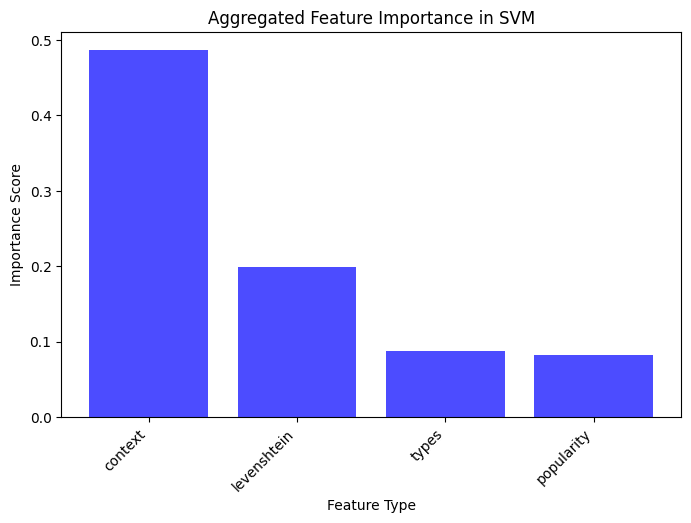

In [7]:
# ---------------------- Train SVM Model ----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train a Support Vector Machine (SVM) model
svm_model = SVC(kernel="linear")  # Linear kernel for interpretability
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# ---------------------- Feature Importance via Permutation ----------------------
perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=10)

importances = perm_importance.importances_mean  # Mean importance scores

# Feature naming
num_candidates = 10  # Assuming 10 candidates per sample
feature_types = ["types", "levenshtein", "popularity", "context"]

# Aggregate importance scores for each type
score_importances = {score: 0 for score in feature_types}

for i in range(num_candidates):
    for j, score in enumerate(feature_types):
        score_importances[score] += importances[i * len(feature_types) + j]

# Convert to lists for plotting
feature_names = list(score_importances.keys())
importance_values = list(score_importances.values())

# Sort feature importances
indices = np.argsort(importance_values)[::-1]

# ---------------------- Visualization ----------------------
plt.figure(figsize=(8, 5))
plt.title("Aggregated Feature Importance in SVM")
plt.bar(range(len(importance_values)), np.array(importance_values)[indices], color="blue", alpha=0.7)
plt.xticks(range(len(importance_values)), np.array(feature_names)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Importance Score")
plt.show()

### Train with all 4 metrics for each candidate

Train 100 copies of SVM, average the results of all runs, and choose the model that best fits the average metrics improtance.

Step:
1. Runs SVM training 100 times and collects feature importances.
2. Averages the feature importances over all runs.
3. Finds the model with the closest importance scores to the average using Euclidean distance.
4. Saves the best model for future use.


Training SVM Models: 100%|██████████████████████████████████████████████████████████| 20/20 [1:01:38<00:00, 184.92s/run]


Best SVM model saved as 'best_svm_model_3.pkl'


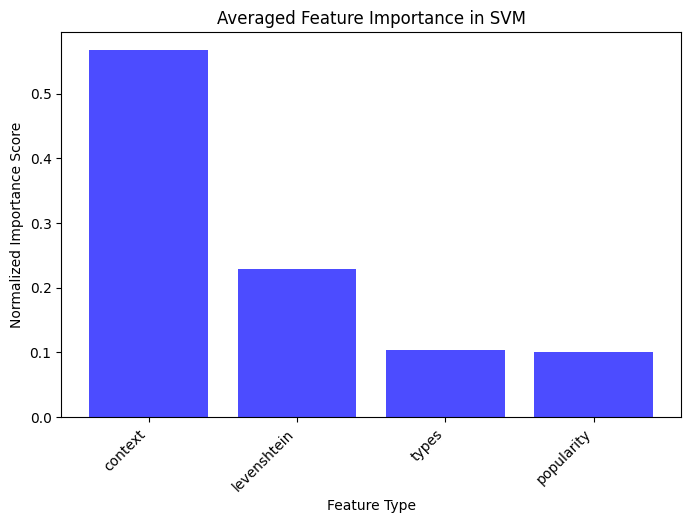

In [9]:
num_runs = 20
num_candidates = 10  # Assuming 10 candidates per sample
feature_types = ["types", "levenshtein", "popularity", "context"]

# Store all feature importances
all_importances = []
all_models = []

# Training loop with tqdm progress bar
for _ in tqdm(range(num_runs), desc="Training SVM Models", unit="run"):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # Train SVM model
    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)

    # Compute permutation importance
    perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=5)
    importances = perm_importance.importances_mean  # Mean importance scores

    # Aggregate importance scores for each feature type
    score_importances = {score: 0 for score in feature_types}

    for i in range(num_candidates):
        for j, score in enumerate(feature_types):
            score_importances[score] += importances[i * len(feature_types) + j]

    # Normalize importance scores to sum to 1
    total_importance = sum(score_importances.values())
    normalized_importances = {k: v / total_importance for k, v in score_importances.items()}

    # Store the results
    all_importances.append(np.array(list(normalized_importances.values())))
    all_models.append(svm_model)

# Compute average importance scores
avg_importance = np.mean(all_importances, axis=0)

# Find the model closest to the average using Euclidean distance
best_index = np.argmin([euclidean(imp, avg_importance) for imp in all_importances])
best_model = all_models[best_index]

# Save the best model
save_model_as_filename = "best_svm_model_4_features_v1.pkl"
joblib.dump(best_model, save_model_as_filename)
print(f"\nBest SVM model saved as '{save_model_as_filename}'")


# ---------------------- Plot Averaged Feature Importances ----------------------
indices = np.argsort(avg_importance)[::-1]
plt.figure(figsize=(8, 5))
plt.title("Averaged Feature Importance in SVM")
plt.bar(range(len(avg_importance)), avg_importance[indices], color="blue", alpha=0.7)
plt.xticks(range(len(avg_importance)), np.array(feature_types)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Normalized Importance Score")
plt.show()

### Train a model using 3 metrics (without the ontology score)

In [10]:
def preprocess_features(X, num_candidates=10, features_per_candidate=4):
    """
    Preprocesses the feature matrix:
    1. Removes the first feature of each candidate.
    2. Computes the sum of the remaining three features.
    3. Sorts candidates by this sum in descending order.
    
    Returns:
        - X_processed: processed and reordered feature matrix (only 3 features per candidate)
        - final_scores_list: list of final scores per candidate (after sorting)
    """
    X_processed = []
    final_scores_list = []

    for row in X:
        candidates = []
        scores = []

        for i in range(num_candidates):
            start_idx = i * features_per_candidate
            # Omit the first feature
            candidate = row[start_idx + 1:start_idx + features_per_candidate].copy()
            score = sum(candidate)
            candidates.append(candidate)
            scores.append(score)

        # Sort candidates by score in descending order
        sorted_candidates = [x for _, x in sorted(zip(scores, candidates), key=lambda pair: pair[0], reverse=True)]
        sorted_scores = sorted(scores, reverse=True)

        # Flatten candidates back to 1D
        sorted_row = np.concatenate(sorted_candidates)
        X_processed.append(sorted_row)
        final_scores_list.append(sorted_scores)

    return np.array(X_processed), final_scores_list


In [15]:
num_runs = 20
num_candidates = 10  # Assuming 10 candidates per sample
feature_types = ["levenshtein", "popularity", "context"]  # 3 features now

all_importances = []
all_models = []

# Preprocess your dataset (X should already be defined)
X_preprocessed, candidate_scores = preprocess_features(X, num_candidates=num_candidates)
print(f"Original X length: {len(X[0])}")
print(f"Modified X length: {len(X_preprocessed[0])}")


Original X length: 40
Modified X length: 30


Training SVM Models: 100%|██████████████████████████████████████████████████████████| 20/20 [1:19:38<00:00, 238.91s/run]


Best SVM model saved as 'best_svm_model_3_features_only_v1.pkl'


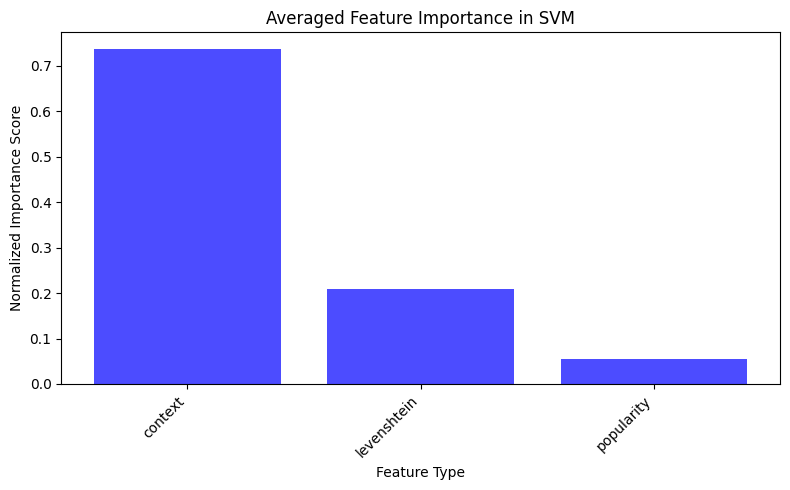

In [16]:
for _ in tqdm(range(num_runs), desc="Training SVM Models", unit="run"):
    X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3)

    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)

    # Permutation importance
    perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=5)
    importances = perm_importance.importances_mean

    # Aggregate importance scores
    score_importances = {score: 0.0 for score in feature_types}

    for i in range(num_candidates):
        for j, score in enumerate(feature_types):
            score_importances[score] += importances[i * len(feature_types) + j]

    total_importance = sum(score_importances.values())
    normalized_importances = {k: v / total_importance for k, v in score_importances.items()}

    all_importances.append(np.array(list(normalized_importances.values())))
    all_models.append(svm_model)

# ------------------------ Post-processing ------------------------

avg_importance = np.mean(all_importances, axis=0)
best_index = np.argmin([euclidean(imp, avg_importance) for imp in all_importances])
best_model = all_models[best_index]

save_model_as_filename = "best_svm_model_3_features_only_v1.pkl"
joblib.dump(best_model, save_model_as_filename)
print(f"\nBest SVM model saved as '{save_model_as_filename}'")

# ------------------------ Visualization ------------------------

indices = np.argsort(avg_importance)[::-1]
plt.figure(figsize=(8, 5))
plt.title("Averaged Feature Importance in SVM")
plt.bar(range(len(avg_importance)), avg_importance[indices], color="blue", alpha=0.7)
plt.xticks(range(len(avg_importance)), np.array(feature_types)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Normalized Importance Score")
plt.tight_layout()
plt.show()

### Test loading the svm from .pth file:

✅ SVM Model Loaded from .pkl


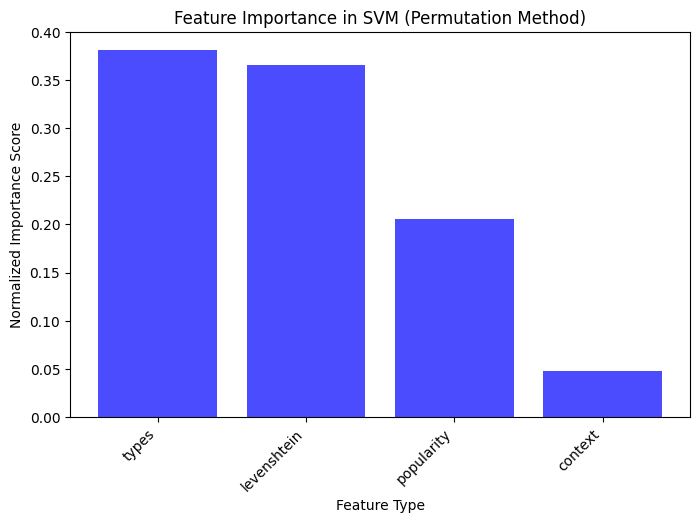


Feature Importances (Sorted):
types: 0.3810
levenshtein: 0.3659
popularity: 0.2055
context: 0.0476


In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import euclidean

# ---------------------- Load .pkl Model ----------------------
svm_model = joblib.load("best_svm_model_1.pkl")
print("✅ SVM Model Loaded from .pkl")

# ------------------------------ Generate Synthetic Data ------------------------------
# Assuming X has 40 features, and y is binary (0 or 1)
np.random.seed(42)
X = np.random.rand(1000, 40)  # 1000 samples, 40 features
y = np.random.choice([0, 1], size=1000)  # Random binary labels

# Feature groups (modify according to your actual feature meanings)
feature_types = ["types", "levenshtein", "popularity", "context"]

# Ensure the feature count is correct
num_candidates = X.shape[1] // len(feature_types)

# ---------------------- Compute Permutation Importance ----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=10, scoring="accuracy")

# Extract mean importance scores
importances = perm_importance.importances_mean

# ---------------------- Aggregate Importance by Feature Type ----------------------
score_importances = {score: 0 for score in feature_types}

for i in range(num_candidates):
    for j, score in enumerate(feature_types):
        score_importances[score] += importances[i * len(feature_types) + j]

# Normalize importance scores to sum to 1
total_importance = sum(score_importances.values())
normalized_importances = {k: v / total_importance for k, v in score_importances.items()}

# ---------------------- Plot Feature Importances ----------------------
indices = np.argsort(list(normalized_importances.values()))[::-1]  # Sort descending
plt.figure(figsize=(8, 5))
plt.title("Feature Importance in SVM (Permutation Method)")
plt.bar(range(len(normalized_importances)), np.array(list(normalized_importances.values()))[indices], color="blue", alpha=0.7)
plt.xticks(range(len(normalized_importances)), np.array(feature_types)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Normalized Importance Score")
plt.show()

# Print sorted feature importances
print("\nFeature Importances (Sorted):")
for feature, importance in sorted(normalized_importances.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.4f}")


## RandomForestClassifier

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
# Train a Random Forest model
model = RandomForestClassifier(n_estimators=1000)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9349


In [ ]:
# Save the trained model using PyTorch
model_path = os.path.join("random_forest_model3.pth")
torch.save(model, model_path)
print(f"Model saved successfully at {model_path}")

Model saved successfully at random_forest_model3.pth


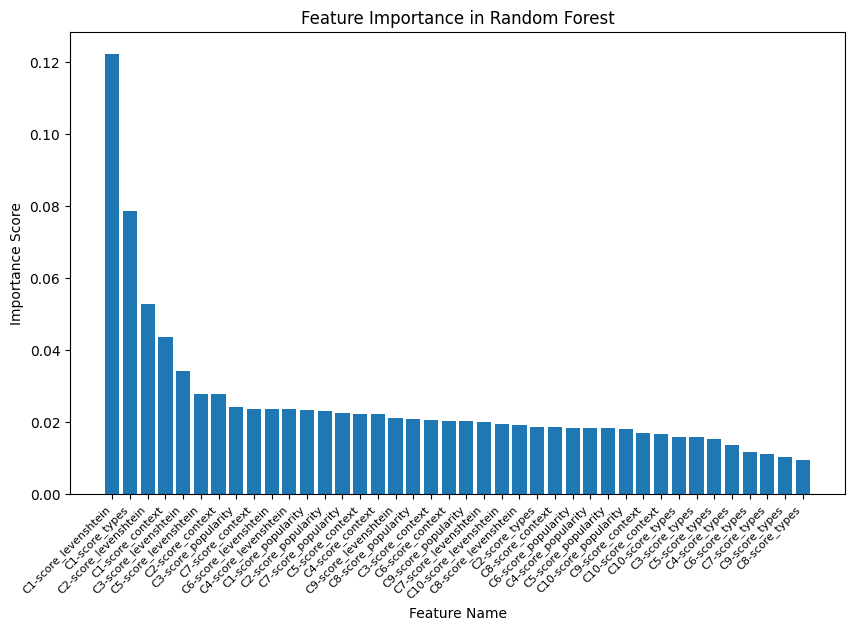

In [ ]:
# Get feature importances
importances = model.feature_importances_
feature_names = [f"C{i+1}-score_{suffix}" for i in range(10) for suffix in ["types", "levenshtein", "popularity", "context"]]

# Create a dictionary mapping feature indices to names
feature_dict = {i: name for i, name in enumerate(feature_names)}

# Sort feature importances
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importance in Random Forest")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_dict[i] for i in indices], rotation=45, ha="right", fontsize=8)
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

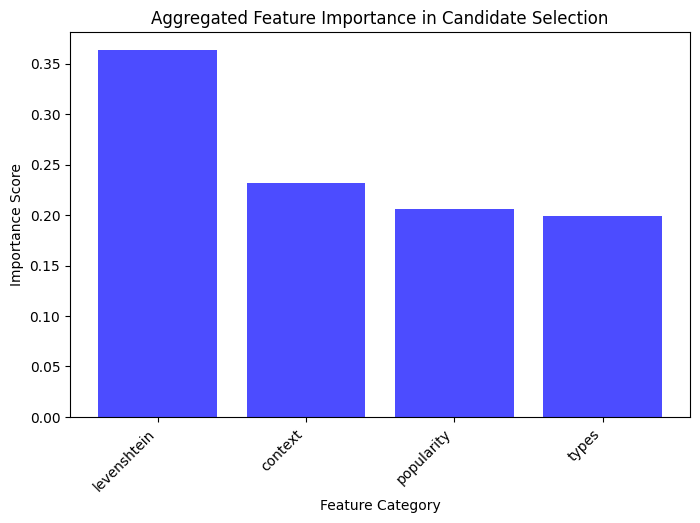

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract feature importances from the trained model
importances = model.feature_importances_

# Define feature categories
num_candidates = 10  # Assuming each candidate has 4 scores (types, levenshtein, popularity, context)
feature_types = ["types", "levenshtein", "popularity", "context"]

# Aggregate importance scores for each type
score_importances = {score: 0 for score in feature_types}

for i in range(num_candidates):
    for j, score in enumerate(feature_types):
        score_importances[score] += importances[i * len(feature_types) + j]

# Convert to lists for plotting
feature_names = list(score_importances.keys())
importance_values = list(score_importances.values())

# Sort feature importances
indices = np.argsort(importance_values)[::-1]

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.title("Aggregated Feature Importance in Candidate Selection")
plt.bar(range(len(importance_values)), np.array(importance_values)[indices], color="blue", alpha=0.7)
plt.xticks(range(len(importance_values)), np.array(feature_names)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Category")
plt.ylabel("Importance Score")
plt.show()


In [ ]:
import pandas as pd
import ast
import os
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

# Evaluate performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Feature importance analysis
importances = model.feature_importances_
feature_names = [f"C{i+1}-score_{suffix}" for i in range(10) for suffix in ["types", "levenshtein", "popularity", "context"]]

# SHAP Analysis for deeper insights
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot for feature importance
shap.summary_plot(shap_values, X_test, feature_names=feature_names)


Model Accuracy: 0.9645


 36%|=======             | 1085/3042 [01:10<02:06]       

In [ ]:
import pandas as pd
import ast
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import os

# Directory containing CSV files
directory_path = "/content/drive/MyDrive/Praca magisterska/Google colab - notebooks/logs_cand_sel"  # Change this to your directory path

# List all CSV files in the directory
csv_files = [f for f in os.listdir(directory_path) if f.endswith(".csv")]

# Read and concatenate all CSV files
dataframes = []
for file in csv_files:
    file_path = os.path.join(directory_path, file)
    df = pd.read_csv(file_path, encoding="utf-16")
    df['candidates'] = df['candidates'].apply(ast.literal_eval)
    dataframes.append(df)

# Combine all dataframes into one
final_df = pd.concat(dataframes, ignore_index=True)

# Extract input features (X) and labels (y)
X = torch.tensor([entry[1:] for candidates in final_df['candidates'] for entry in candidates], dtype=torch.float32)
y = torch.tensor(final_df['matching_candidate_index'].values, dtype=torch.long)

# Reshape X into (num_samples, 10, 4) where 10 candidates each have 4 metrics
X = X.view(len(final_df), 10, 4)  # Each row corresponds to 10 candidates

In [ ]:
class CandidateSelectorNN(nn.Module):
    def __init__(self):
        super(CandidateSelectorNN, self).__init__()
        self.fc1 = nn.Linear(4, 16)  # Input: 4 metrics -> Hidden layer
        self.fc2 = nn.Linear(16, 8)  # Hidden layer
        self.fc3 = nn.Linear(8, 1)   # Output: Score for each candidate

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze(-1)  # Shape: (batch_size, 10)


In [ ]:
class CandidateDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CandidateDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CandidateSelectorNN().to(device)
criterion = nn.CrossEntropyLoss()  # Suitable for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 200
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)  # Shape: (batch_size, 10)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {correct / total:.4f}")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

print(f"Test Accuracy: {correct / total:.4f}")


In [ ]:
torch.save(model.state_dict(), "candidate_selector_model.pth")


In [ ]:
# Recreate the model architecture
model = CandidateSelectorNN()

# Load saved weights
model.load_state_dict(torch.load("candidate_selector_model.pth"))

# Set model to evaluation mode
model.eval()


## analysing data quality

In [44]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Assuming X and y are your feature and target arrays
num_candidates = 10
num_metrics = 4

avg_metric_differences = []
for i in range(len(y)):
    best_candidate_index = y[i]
    start_best = best_candidate_index * num_metrics
    end_best = (best_candidate_index + 1) * num_metrics
    best_candidate_features = X[i, start_best:end_best]

    differences_per_candidate = []
    for other_candidate_index in range(num_candidates):
        if other_candidate_index != best_candidate_index:
            start_other = other_candidate_index * num_metrics
            end_other = (other_candidate_index + 1) * num_metrics
            other_candidate_features = X[i, start_other:end_other]
            difference = best_candidate_features - other_candidate_features
            differences_per_candidate.append(difference)

    avg_difference = np.mean(differences_per_candidate, axis=0) # Average across candidates
    avg_metric_differences.append(avg_difference)

avg_metric_differences_array = np.array(avg_metric_differences)

# Analyze correlation of average metric differences with the target index
feature_types = ["types", "levenshtein", "popularity", "context"]
print("Pearson Correlations of Average Metric Differences (Best vs. Others) with Target Index:")
for m in range(num_metrics):
    correlation, p_value = pearsonr(avg_metric_differences_array[:, m], y)
    print(f"  Average Difference in {feature_types[m]}: {correlation:.4f} (p-value: {p_value:.4f})")

# You can also analyze the sum and average of these average differences
sum_of_avg_differences = np.sum(avg_metric_differences_array, axis=1)
avg_of_avg_differences = np.mean(avg_metric_differences_array, axis=1)

correlation_sum_avg_diff, p_value_sum_avg_diff = pearsonr(sum_of_avg_differences, y)
print(f"\nPearson Correlation of Sum of Average Metric Differences with Target Index: {correlation_sum_avg_diff:.4f} (p-value: {p_value_sum_avg_diff:.4f})")

correlation_avg_avg_diff, p_value_avg_avg_diff = pearsonr(avg_of_avg_differences, y)
print(f"Pearson Correlation of Average of Average Metric Differences with Target Index: {correlation_avg_avg_diff:.4f} (p-value: {p_value_avg_avg_diff:.4f})")

Pearson Correlations of Average Metric Differences (Best vs. Others) with Target Index:
  Average Difference in types: -0.5016 (p-value: 0.0000)
  Average Difference in levenshtein: -0.2701 (p-value: 0.0000)
  Average Difference in popularity: -0.4976 (p-value: 0.0000)
  Average Difference in context: 0.1660 (p-value: 0.0000)

Pearson Correlation of Sum of Average Metric Differences with Target Index: -0.7836 (p-value: 0.0000)
Pearson Correlation of Average of Average Metric Differences with Target Index: -0.7836 (p-value: 0.0000)


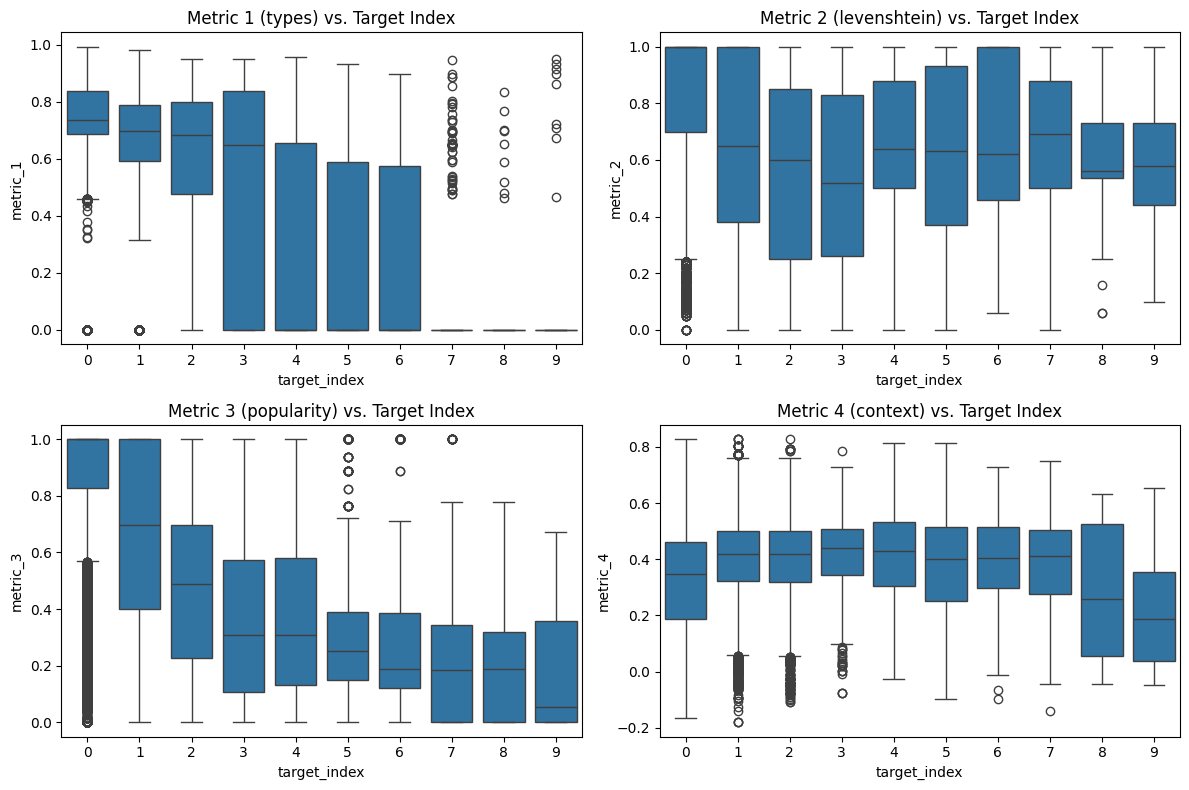

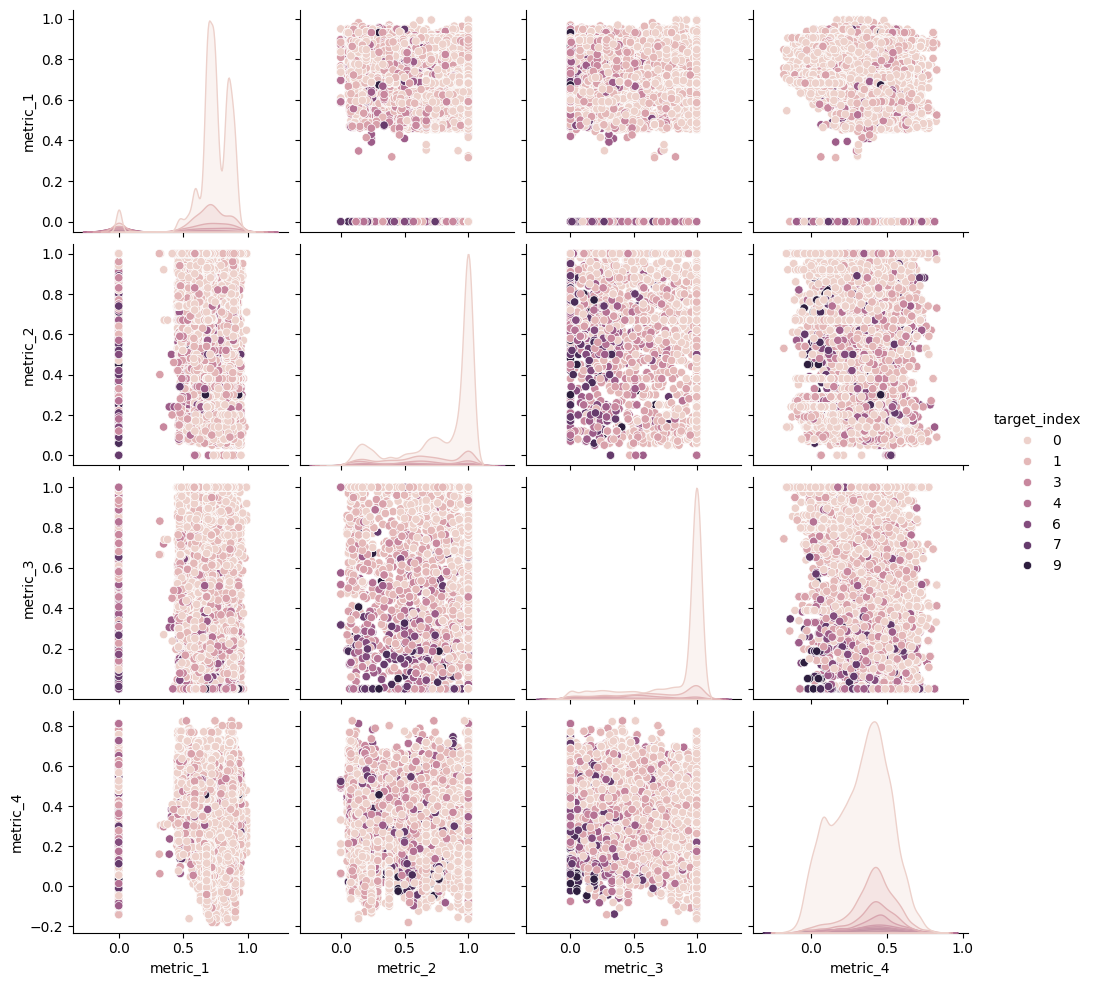

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X and y are your feature and target arrays
num_candidates = 10
num_metrics = 4

best_candidate_metrics = []
for i in range(len(y)):
    best_candidate_index = y[i]
    start_index = best_candidate_index * num_metrics
    end_index = (best_candidate_index + 1) * num_metrics
    best_candidate_features = X[i, start_index:end_index]
    best_candidate_metrics.append(best_candidate_features)
best_candidate_metrics_array = np.array(best_candidate_metrics)

df_best_metrics = pd.DataFrame(best_candidate_metrics_array, columns=[f'metric_{i+1}' for i in range(num_metrics)])
df_best_metrics['target_index'] = y

# Box plots
plt.figure(figsize=(12, 8))
for i in range(num_metrics):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='target_index', y=f'metric_{i+1}', data=df_best_metrics)
    plt.title(f'Metric {i+1} ({feature_types[i]}) vs. Target Index')
plt.tight_layout()
plt.show()

# Pair plot (can be computationally expensive if many samples)
sns.pairplot(df_best_metrics, hue='target_index')
plt.show()